<a href="https://colab.research.google.com/github/rimi-1234/cse366_first_LAB/blob/master/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
import matplotlib.pyplot as plt

In [12]:
class PriceMonitoringController:
    def __init__(self):
        self.average_price = 600
        self.price_drop_threshold = 0.8

    def update_average_price(self, current_price):
        """Update the average price using an exponential moving average (EMA)."""
        self.average_price = self.average_price + (current_price - self.average_price) * 0.05

    def check_price_change(self, current_price):
        """Check if the current price is significantly lower than the average price."""
        self.update_average_price(current_price)
        print(f"Average Price: {self.average_price:.2f}, Current Price: {current_price}")
        return current_price < self.average_price * self.price_drop_threshold

In [3]:
class InventoryMonitoringController:
    def __init__(self):
        self.critical_stock_threshold = 10

    def check_stock(self, instock):
        """Check if stock is below the critical threshold."""
        print(f"Stock Level: {instock}")
        return instock < self.critical_stock_threshold


In [4]:
class OrderingController:
    def __init__(self):
        self.order_minimum = 10
        self.order_maximum = 20

    def decide_order(self, price_change, stock_status, current_stock):
        """Decide the order based on price change, stock status, and current stock level."""
        if price_change and  stock_status:
            order_quantity = 15

            return {'buy': order_quantity}

        elif stock_status:
            print(f"Condition met: Critical stock level, buying minimum ({self.order_minimum} items).")
            return {'buy': self.order_minimum}

        else:
            print("Condition met: No action required, no items purchased.")
            return {'buy': 0}


In [5]:
class Plot_history:
    """Plot price, stock, and buying actions in one figure."""
    def __init__(self, ag, env):
        self.ag = ag
        self.env = env

    def plot_combined(self):
        """Plot price, stock, and buying in one figure."""
        plt.figure(figsize=(12, 6))

        # Plot Price History
        plt.plot(self.env.price_history, label="Price", color="blue", linestyle='-')

        # Plot Stock History
        plt.plot(self.env.stock_history, label="Stock Level", color="green", linestyle='--')

        # Plot Buying History (as bar chart)
        plt.bar(range(1, len(self.ag.buy_history) + 1), self.ag.buy_history, label="Quantity Bought", color="orange", alpha=0.6)

        # Add labels, title, legend, and grid
        plt.xlabel("Time")
        plt.ylabel("Values")
        plt.title("Price, Stock Level, and Buying History")
        plt.legend()
        plt.grid(True)

        # Show the plot
        plt.show()

In [6]:
# Environment class
class TP_env:
    def __init__(self):
        self.time = 0
        self.stock = 20
        self.price = 600
        self.price_delta = [0, 0, 0, -60, 0, -70, 0, -64, 0, 0, 23, 0, 0, 0, -35, 0, -80, 0, -41]
        self.stock_history = [self.stock]
        self.price_history = [self.price]

    def initial_percept(self):
        """Returns the initial percept."""
        return {'price': self.price, 'instock': self.stock}

    def do(self, action):
        used = self.select_from_dist({6: 0.1, 5: 0.1, 4: 0.1, 3: 0.3, 2: 0.2, 1: 0.2})
        bought = action.get('buy', 0)
        self.stock += bought
        self.stock -= used

        price_change = self.price_delta[self.time % len(self.price_delta)]
        self.price += price_change + random.gauss(0, 2)

        # Update history
        self.stock_history.append(self.stock)
        self.price_history.append(self.price)

        self.time += 1
        return {'price': self.price, 'instock': self.stock}

    def select_from_dist(self, item_prob_dist):
        """Select an item based on probability distribution."""
        ranreal = random.random()
        cumulative_prob = 0.0
        for (item, prob) in item_prob_dist.items():
            cumulative_prob += prob
            if ranreal < cumulative_prob:
                return item
        return list(item_prob_dist.keys())[-1]


In [7]:
# Agent class
class TP_agent:
    def __init__(self):
        self.price_monitor = PriceMonitoringController()
        self.inventory_monitor = InventoryMonitoringController()
        self.ordering_controller = OrderingController()
        self.buy_history = []

    def select_action(self, percept):
        price = percept['price']
        instock = percept['instock']

        price_change = self.price_monitor.check_price_change(price)
        stock_status = self.inventory_monitor.check_stock(instock)

        action = self.ordering_controller.decide_order(price_change, stock_status, instock)
        self.buy_history.append(action['buy'])
        return action


In [8]:

# Simulate the process
class Simulate:
    def __init__(self, agent, environment):
        self.agent = agent
        self.environment = environment
        self.percept = self.environment.initial_percept()

    def go(self, n):
        for i in range(n):
            print(f"Step {i+1}:")
            action = self.agent.select_action(self.percept)
            print(f"    Action: {action}")
            self.percept = self.environment.do(action)
            print(f"    Percept: {self.percept}\n")


In [9]:
env = TP_env()
agent = TP_agent()
simulation = Simulate(agent, env)
simulation.go(50)

Step 1:
Average Price: 600.00, Current Price: 600
Stock Level: 20
Condition met: No action required, no items purchased.
    Action: {'buy': 0}
    Percept: {'price': 601.7996386412626, 'instock': 19}

Step 2:
Average Price: 600.09, Current Price: 601.7996386412626
Stock Level: 19
Condition met: No action required, no items purchased.
    Action: {'buy': 0}
    Percept: {'price': 600.3937291852941, 'instock': 16}

Step 3:
Average Price: 600.11, Current Price: 600.3937291852941
Stock Level: 16
Condition met: No action required, no items purchased.
    Action: {'buy': 0}
    Percept: {'price': 599.6113721933085, 'instock': 12}

Step 4:
Average Price: 600.08, Current Price: 599.6113721933085
Stock Level: 12
Condition met: No action required, no items purchased.
    Action: {'buy': 0}
    Percept: {'price': 540.7134199836318, 'instock': 7}

Step 5:
Average Price: 597.11, Current Price: 540.7134199836318
Stock Level: 7
Condition met: Critical stock level, buying minimum (10 items).
    Acti

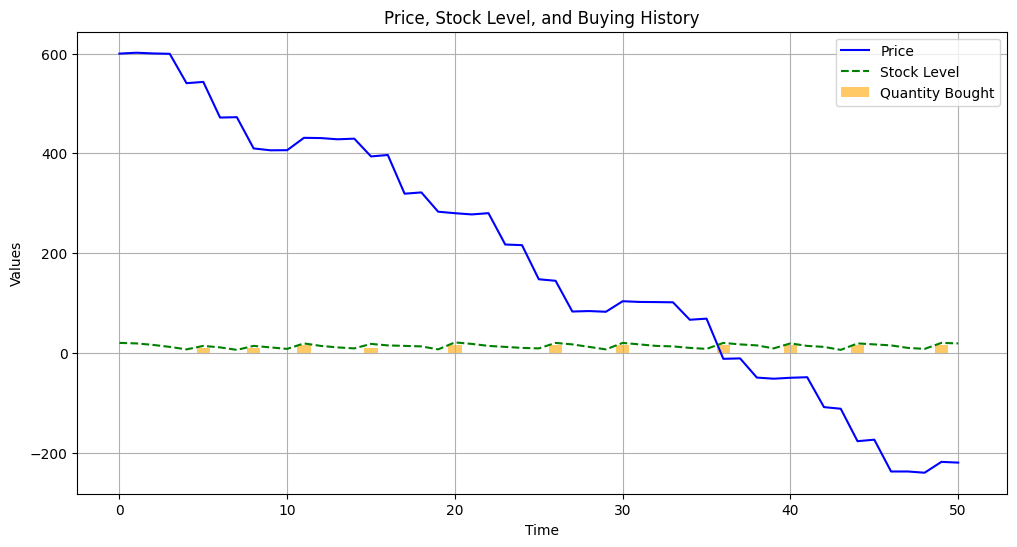

In [11]:
# Plot the results
plotter = Plot_history(agent, env)
plotter.plot_combined()


# New section